# Continuous housing investment with frictions: EGM(FUES) vs NEGM(FUES)

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
    nb_plot_value_functions,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/separable'
print('Ready')

Ready


## 2. Solve

In [ ]:
OVERRIDES = dict(
    setting_overrides={
        'store_cntn': 1, 'N_wage': 4,
        'n_w': 900, 'n_a': 900, 'n_h': 900, 'n_sections': 1   
    },
    calib_overrides={
        't0': 20, 'tau': 0.07
    },
)

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        nest, grids = solve(
            SYNTAX, method=method,
            verbose=False, progress='bar',
            **OVERRIDES)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

EGM(FUES)


    solve(method=...) is deprecated; use method_overrides instead.
    Settings symbol 'n_sections' (for cntn_to_dcsn_mover.n_sections) not declared in stage symbols.settings
Solving: 100%|██████████| 51/51 [00:38<00:00,  1.31it/s, age=20, avg_adj_ms=9, avg_keeper_ms=44] 

NEGM(FUES)



    solve(method=...) is deprecated; use method_overrides instead.
    Settings symbol 'n_sections' (for cntn_to_dcsn_mover.n_sections) not declared in stage symbols.settings
Solving: 100%|██████████| 51/51 [00:18<00:00,  2.78it/s, age=20, avg_adj_ms=24, avg_keeper_ms=44]


  51 periods, ages 20–70
  r=0.045, R=1.045, r_H=0, R_H=1.0, beta=0.945, alpha=0.7, gamma_c=3.5, gamma_h=1.5, kappa=0.06, sigma=0.001, delta=0, tau=0.07, chi=0, theta=1.3498, K=1.3, lambdas=[4.329982, 0.610214, -0.0209832, 0.0003132, -1.72e-06, 0.0199949, 4.76e-05], tau_av=30
  n_a=300, n_h=300, n_w=300, N_wage=4

  Method            Keeper    Adjuster      Tenure     Total
                (ms/period)  (ms/period)  (ms/period)     (sec)
  ────────────────────────────────────────────────────────────
  EGM(FUES)             44           9         167        39
  NEGM(FUES)            44          24         163        18


## 3. Adjuster policies

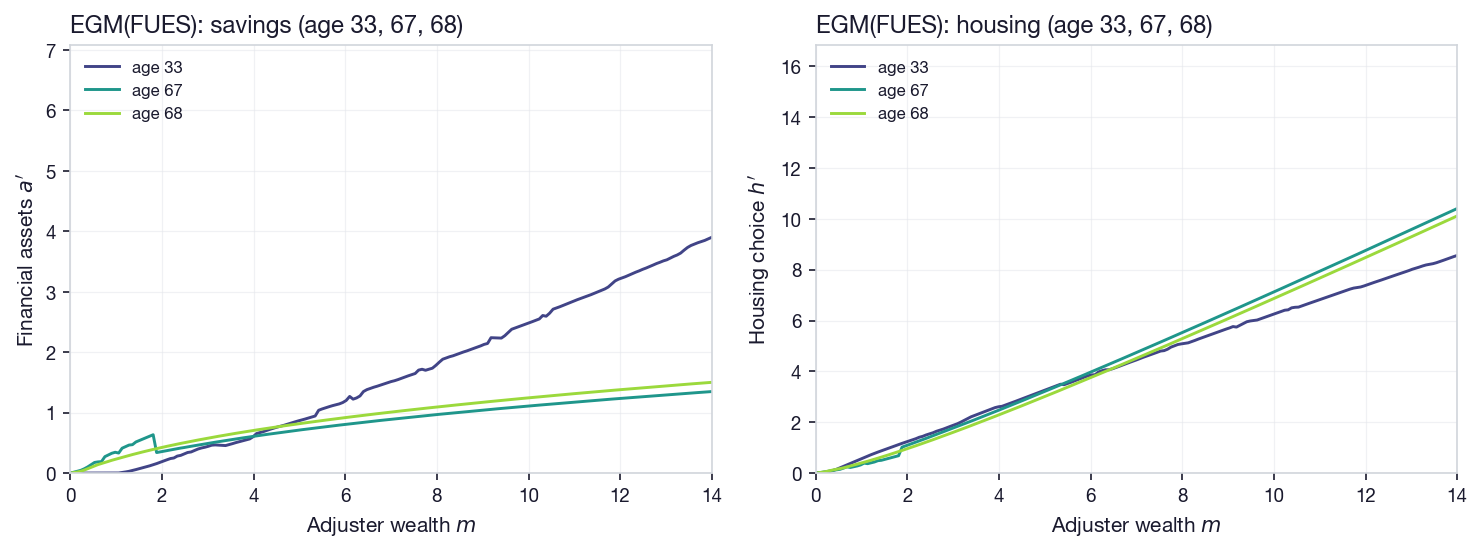

In [3]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[33, 67, 68], methods_filter=['FUES'], i_z=0)

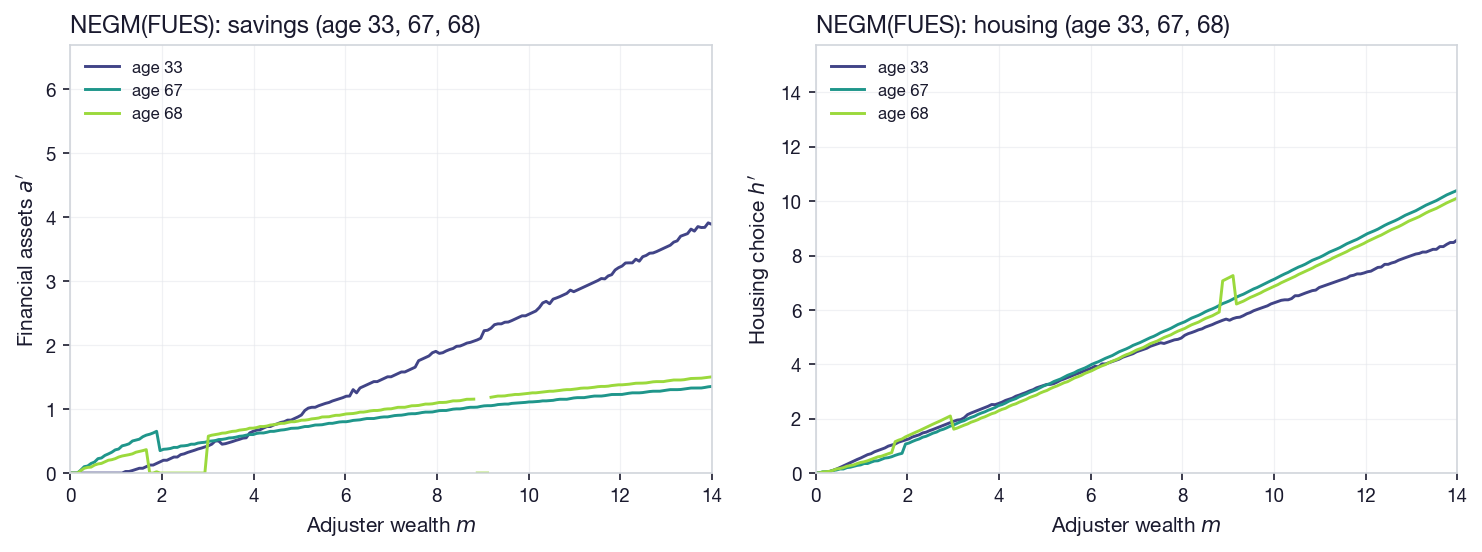

In [4]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[33, 67, 68], methods_filter=['NEGM'], i_z=0)

#fig = nb_plot_value_functions(
#    results, results['FUES']['grids'], plot_t=67)


## 4. Adjuster EGM grid

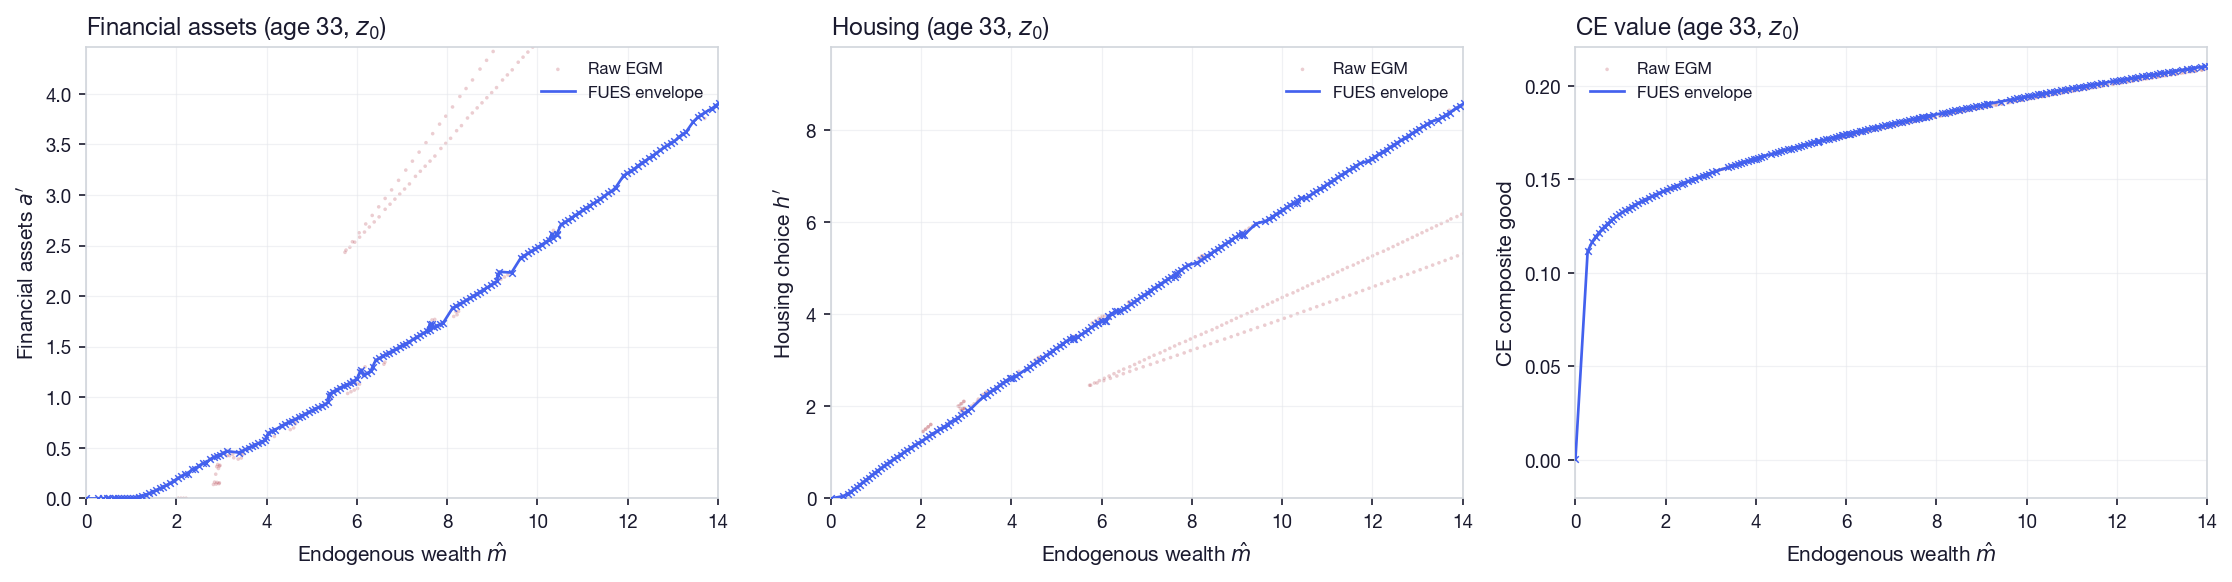

In [5]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=33)

In [6]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=33)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies

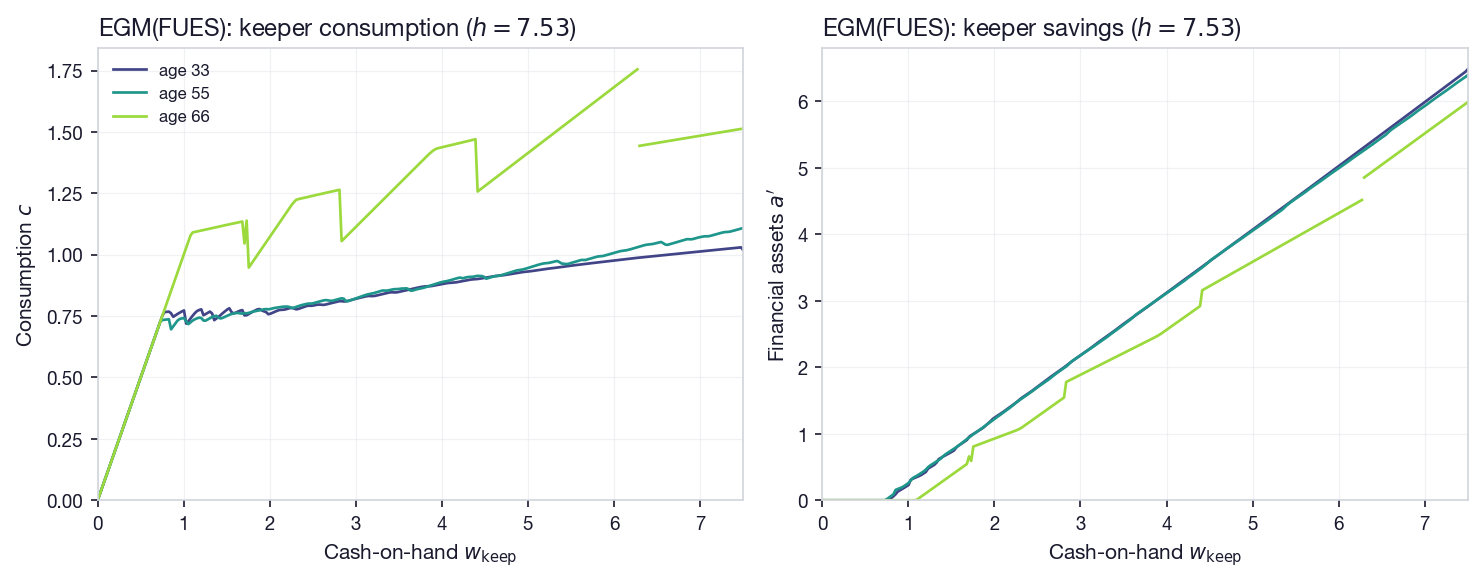

In [7]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[33, 55, 66], methods_filter=['FUES'])

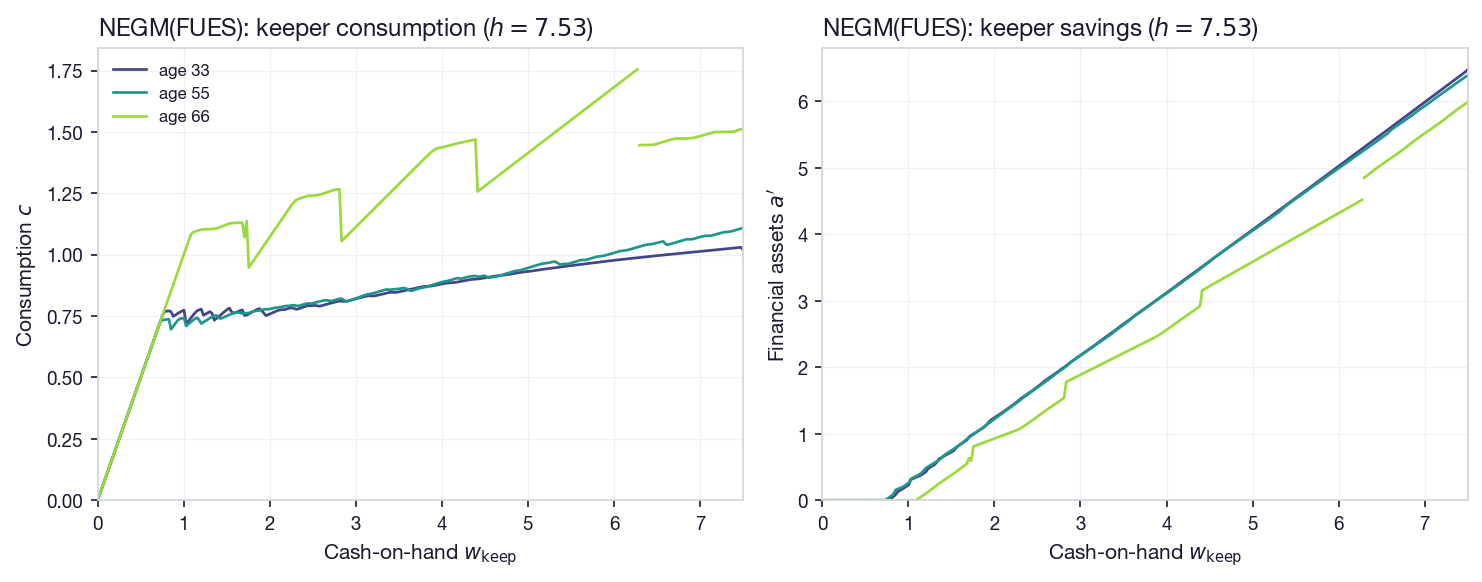

In [8]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[33, 55, 66], methods_filter=['NEGM'])

## 6. Euler equation errors

In [9]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(r['nest'], r['grids'], N=20_000, seed=21)
    euler_c = evaluate_euler_c(sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c, 'euler_h': euler_h, 'euler': euler_c,
        'stats_c': compute_euler_stats(euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


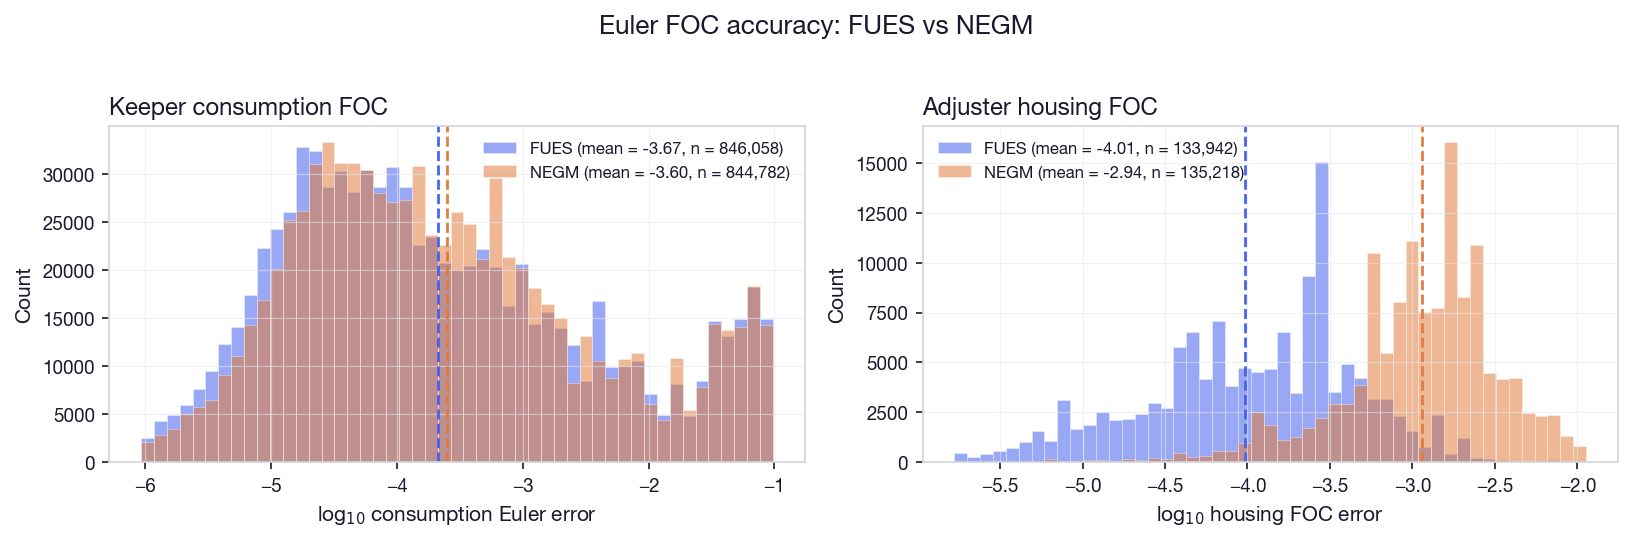

In [10]:
fig = plot_euler_histogram(euler_results)

## 7. Comparison of aggregates

In [11]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))

### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 44 | 44 |
| Adjuster (ms/period) | 9 | 24 |
| Total (ms/period) | 220 | 231 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -3.67 | -3.60 |
| Consumption: adjuster | -1.82 | -1.82 |
| Consumption: all | -3.42 | -3.36 |
| Housing: adjuster | -4.01 | -2.94 |
| **Simulation** |  |  |
| CE utility | 12,957.78 | 12,957.55 |
| Mean consumption ($) | 62,637 | 62,623 |
| Mean fin. assets ($) | 67,097 | 66,738 |
| Mean housing ($) | 247,071 | 247,405 |
| Adjustment rate (%) | 14.8 | 15.1 |

## 8. Lifecycle profiles

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


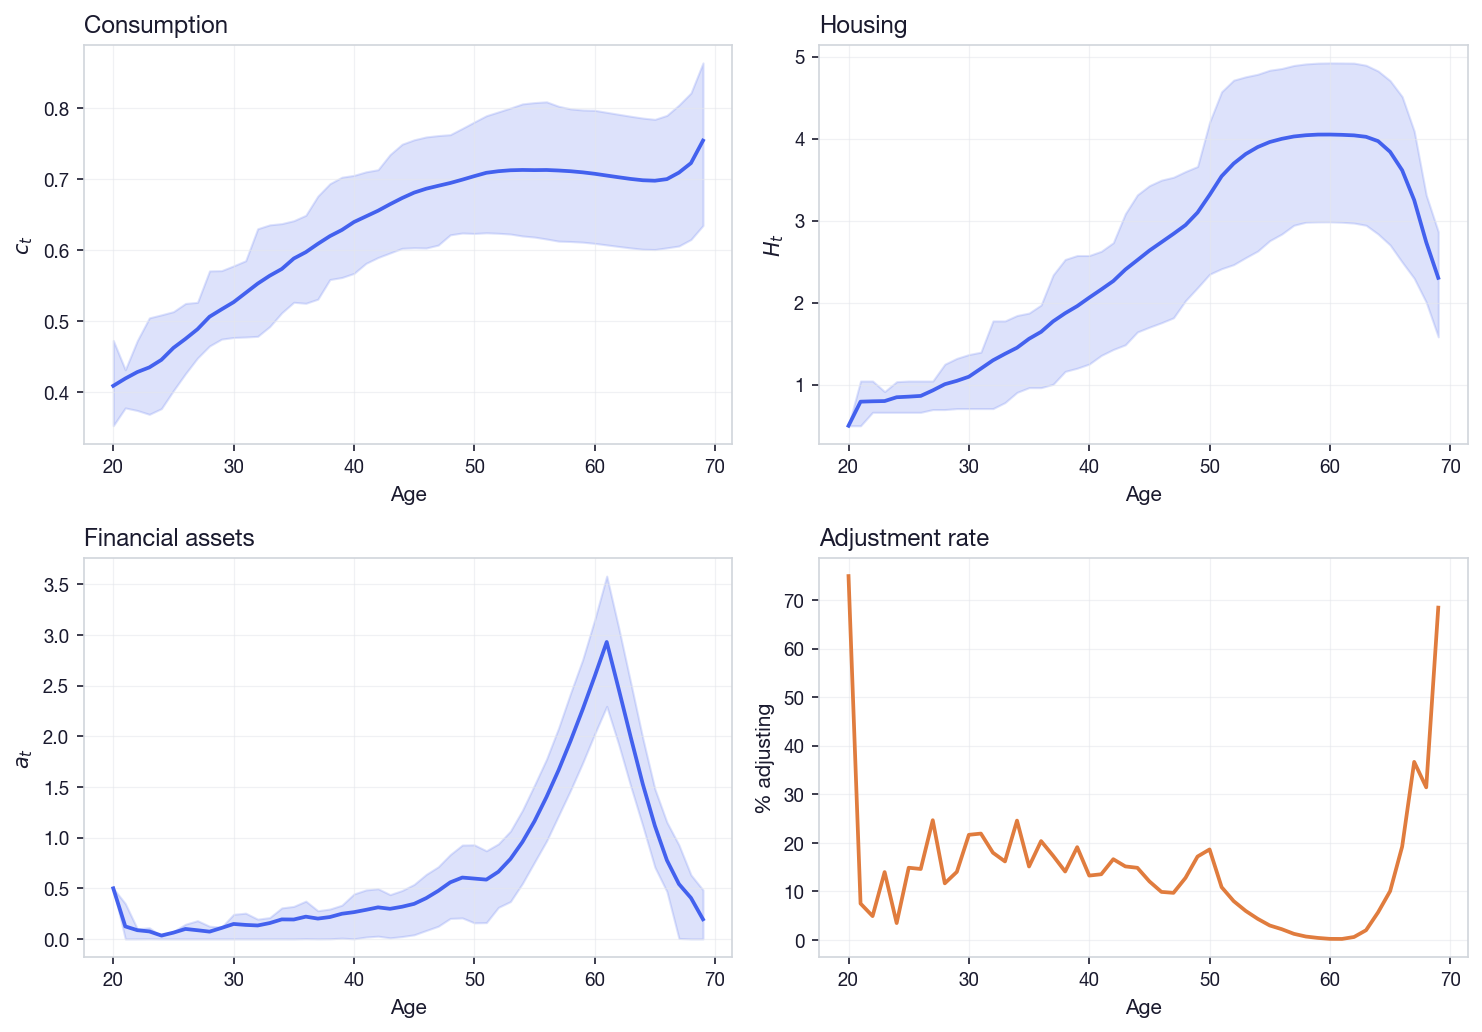

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


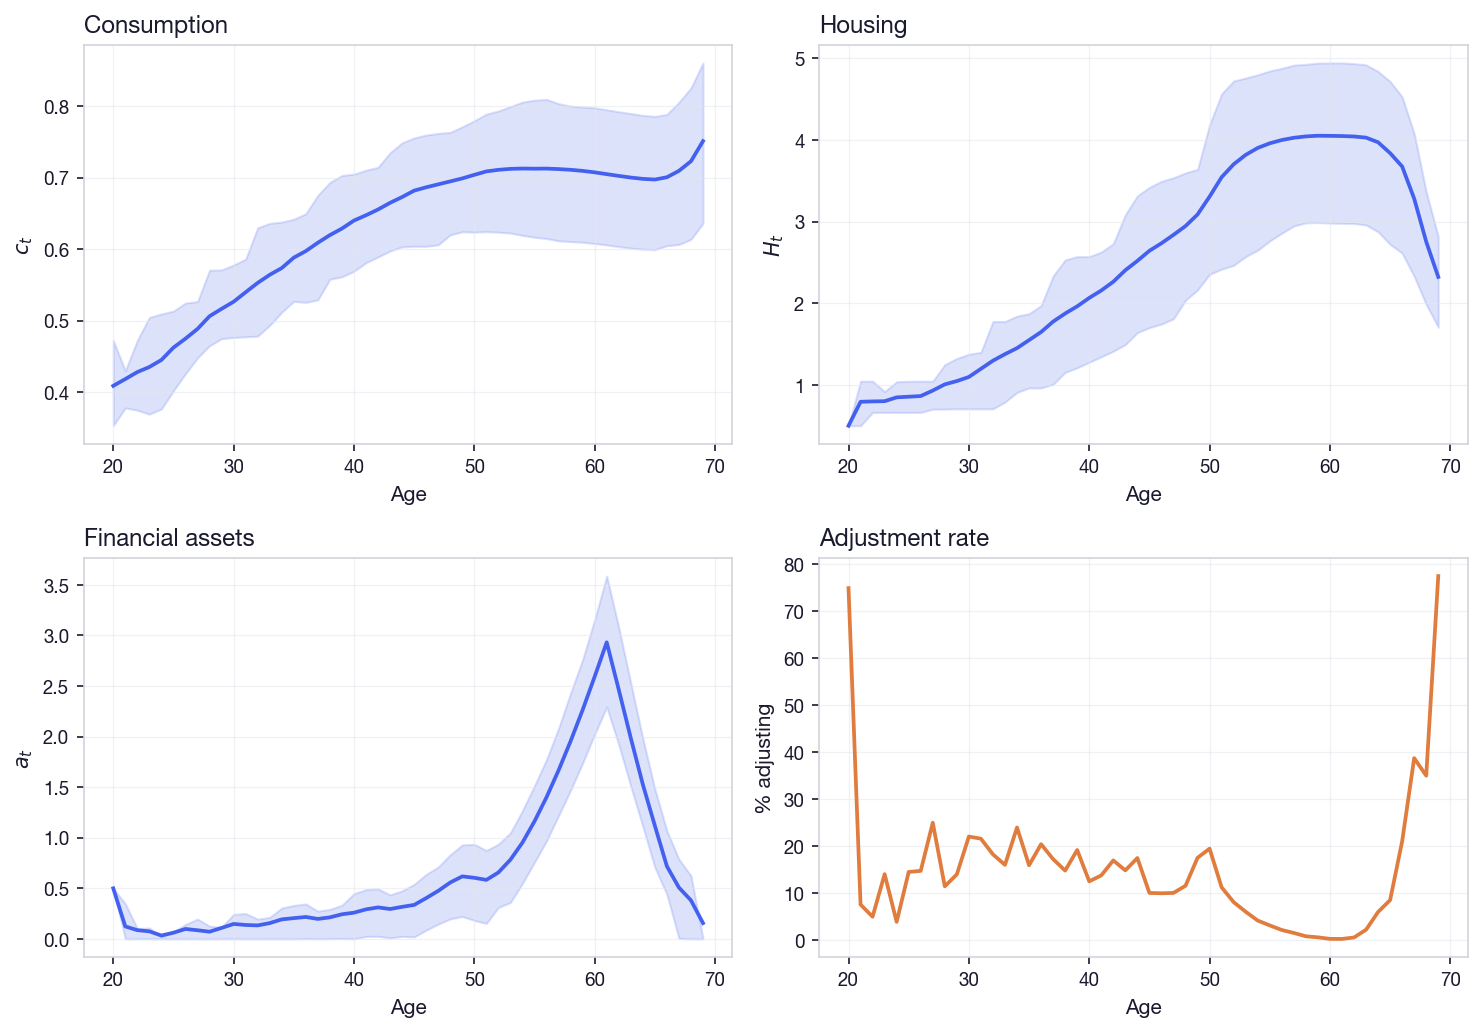

In [12]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

In [13]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 42,719.45 | 7,313.85 | 16,353.31 | 19,201.57 | 74,802.32 | 23,510.65 |
| 25–29 | 48,963.89 | 8,295.30 | 8,550.30 | 12,719.17 | 94,061.84 | 40,291.04 |
| 30–34 | 55,123.61 | 8,775.34 | 15,381.40 | 19,566.85 | 128,384.31 | 63,449.20 |
| 35–39 | 60,837.85 | 9,110.33 | 21,556.79 | 25,545.68 | 176,138.16 | 82,617.23 |
| 40–44 | 65,605.40 | 9,387.08 | 29,587.71 | 33,282.52 | 228,195.02 | 100,315.01 |
| 45–49 | 69,031.77 | 9,846.20 | 47,778.81 | 44,889.85 | 285,126.79 | 116,616.09 |
| 50–54 | 70,987.99 | 11,142.24 | 71,849.31 | 55,776.06 | 365,190.28 | 139,210.76 |
| 55–59 | 71,162.40 | 12,507.54 | 169,052.23 | 78,154.35 | 401,430.63 | 141,063.53 |
| 60–64 | 70,270.71 | 12,737.88 | 230,142.06 | 95,106.59 | 402,519.83 | 141,469.97 |
| 65–69 | 71,670.29 | 13,897.12 | 60,718.41 | 54,578.50 | 314,865.77 | 133,628.97 |

**NEGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 42,714.37 | 7,280.05 | 16,375.50 | 19,211.89 | 74,796.34 | 23,589.60 |
| 25–29 | 48,966.09 | 8,306.92 | 8,526.49 | 12,704.08 | 94,098.22 | 40,463.45 |
| 30–34 | 55,129.71 | 8,808.30 | 15,386.00 | 19,537.18 | 128,397.26 | 63,539.59 |
| 35–39 | 60,846.65 | 9,107.53 | 21,548.31 | 25,832.59 | 176,194.26 | 82,928.93 |
| 40–44 | 65,595.59 | 9,397.71 | 29,527.12 | 33,215.54 | 228,205.97 | 100,520.81 |
| 45–49 | 69,036.51 | 9,827.53 | 47,808.35 | 45,015.30 | 284,988.48 | 116,499.38 |
| 50–54 | 70,952.99 | 11,125.52 | 71,605.01 | 55,836.20 | 365,456.51 | 139,355.40 |
| 55–59 | 71,132.57 | 12,516.88 | 168,950.17 | 77,829.74 | 401,633.06 | 141,542.04 |
| 60–64 | 70,245.10 | 12,740.98 | 229,991.72 | 94,912.94 | 402,841.61 | 141,807.35 |
| 65–69 | 71,608.39 | 13,917.25 | 57,660.71 | 54,085.54 | 317,441.61 | 132,010.86 |